# Support Vector Machine (SVM) from Scratch

This notebook builds a binary SVM classifier entirely from scratch using NumPy and then benchmarks it against scikit-learn's implementation on the same dataset.

## What we're covering

1. The math behind SVMs: margin maximization and the hinge loss
2. Training with mini-batch stochastic gradient descent (SGD)
3. Linear kernel classification on a 2D toy dataset
4. Decision boundary visualization
5. Side-by-side accuracy comparison with sklearn

---

## 1. A Quick Theory Refresher

A hard-margin SVM finds a hyperplane $\mathbf{w}^T \mathbf{x} + b = 0$ that separates two classes while maximizing the margin between them. In practice the data is rarely linearly separable, so we relax the constraints with slack variables $\xi_i \geq 0$ and solve:

$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i$$

subject to $y_i (\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i$

This is equivalent to minimizing the **regularized hinge loss**:

$$J(\mathbf{w}, b) = \frac{\lambda}{2} \|\mathbf{w}\|^2 + \frac{1}{n} \sum_{i=1}^{n} \max\left(0,\; 1 - y_i (\mathbf{w}^T \mathbf{x}_i + b)\right)$$

where $\lambda = 1/C$ controls the regularization strength. The subgradients used during SGD are:

$$\frac{\partial J}{\partial \mathbf{w}} = \lambda \mathbf{w} - \frac{1}{|B|} \sum_{i \in B} \mathbf{1}[y_i f_i < 1]\, y_i \mathbf{x}_i$$

$$\frac{\partial J}{\partial b} = - \frac{1}{|B|} \sum_{i \in B} \mathbf{1}[y_i f_i < 1]\, y_i$$

where $f_i = \mathbf{w}^T \mathbf{x}_i + b$ and $B$ is a mini-batch.

---

## 2. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)
print('All imports OK')

All imports OK


## 3. Dataset

In [2]:
# Synthetic binary classification dataset
X, y = make_classification(
    n_samples=600,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

# SVM loss uses labels in {-1, +1}
y_svm = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_svm, test_size=0.25, random_state=42
)

# Feature scaling is important for gradient-based SVM training
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train size : {X_train.shape}')
print(f'Test  size : {X_test.shape}')
print(f'Class balance (train): {np.bincount(y_train == 1)}')

Train size : (450, 2)
Test  size : (150, 2)
Class balance (train): [227 223]


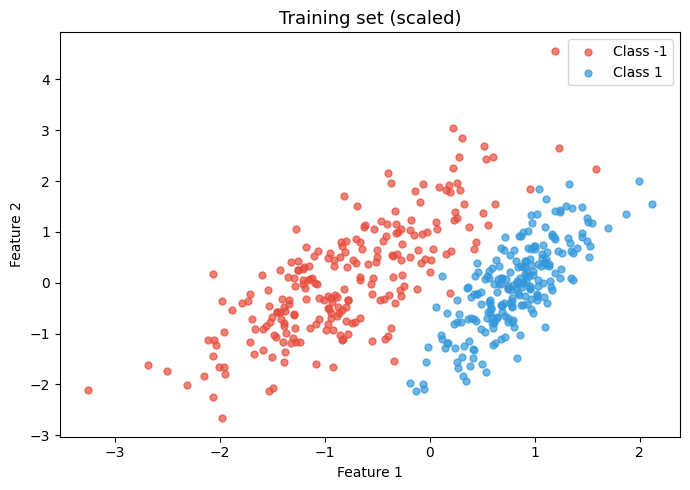

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = {-1: '#e74c3c', 1: '#3498db'}
for label, color in colors.items():
    mask = y_train == label
    ax.scatter(X_train[mask, 0], X_train[mask, 1],
               c=color, s=25, alpha=0.7,
               label=f'Class {label}')

ax.set_title('Training set (scaled)', fontsize=13)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
plt.tight_layout()
plt.show()

## 4. SVM Implementation

In [4]:
class LinearSVM:
    """
    Soft-margin linear SVM trained with mini-batch SGD
    on the regularized hinge loss.

    Parameters
    ----------
    C          : regularization parameter (higher = less regularization)
    lr         : initial learning rate
    n_epochs   : number of full passes through the training data
    batch_size : number of samples per gradient update
    """

    def __init__(self, C=1.0, lr=0.01, n_epochs=200, batch_size=32):
        self.C          = C
        self.lr         = lr
        self.n_epochs   = n_epochs
        self.batch_size = batch_size

        self.w          = None
        self.b          = None
        self.loss_hist  = []

    # ------------------------------------------------------------------
    # Private helpers
    # ------------------------------------------------------------------

    def _hinge_loss(self, X, y):
        """Regularized hinge loss over a batch."""
        margins = y * (X @ self.w + self.b)           # shape (n,)
        hinge   = np.maximum(0, 1 - margins)           # per-sample loss
        reg     = 0.5 * (1 / self.C) * np.dot(self.w, self.w)
        return reg + hinge.mean()

    def _gradients(self, X_b, y_b):
        """Subgradients of the hinge loss for a mini-batch."""
        n       = len(y_b)
        margins = y_b * (X_b @ self.w + self.b)

        # Indicator: which samples are on the wrong side of the margin
        mask    = (margins < 1).astype(float)          # shape (n,)

        dw = (1 / self.C) * self.w - (1 / n) * (mask * y_b) @ X_b
        db = -(1 / n) * (mask * y_b).sum()
        return dw, db

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Xavier-style initialization
        self.w = np.zeros(n_features)
        self.b = 0.0

        rng = np.random.default_rng(0)

        for epoch in range(self.n_epochs):
            # Shuffle every epoch
            idx = rng.permutation(n_samples)
            X_s, y_s = X[idx], y[idx]

            # Learning rate schedule: gentle decay
            lr_t = self.lr / (1 + 0.01 * epoch)

            for start in range(0, n_samples, self.batch_size):
                X_b = X_s[start : start + self.batch_size]
                y_b = y_s[start : start + self.batch_size]

                dw, db = self._gradients(X_b, y_b)
                self.w -= lr_t * dw
                self.b -= lr_t * db

            # Record full-batch loss once per epoch
            self.loss_hist.append(self._hinge_loss(X, y))

        return self

    def decision_function(self, X):
        """Raw margin scores."""
        return X @ self.w + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X)).astype(int)


print('LinearSVM class defined.')

LinearSVM class defined.


## 5. Training

In [5]:
svm = LinearSVM(C=1.0, lr=0.1, n_epochs=300, batch_size=32)
svm.fit(X_train, y_train)

print(f'Final hinge loss : {svm.loss_hist[-1]:.4f}')
print(f'Learned w        : {svm.w}')
print(f'Learned b        : {svm.b:.4f}')

Final hinge loss : 0.6986
Learned w        : [ 0.68772876 -0.120965  ]
Learned b        : 0.0961


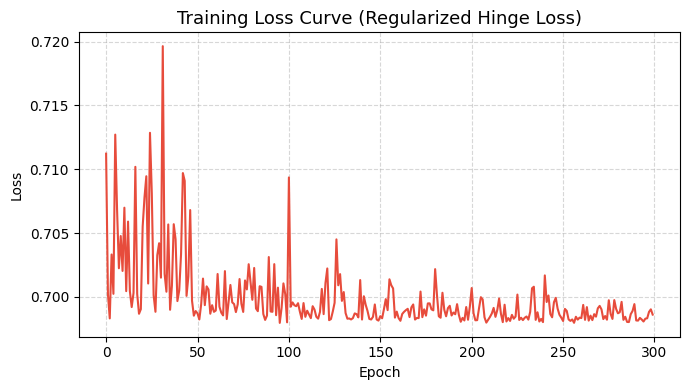

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(svm.loss_hist, color='#e74c3c', linewidth=1.5)
ax.set_title('Training Loss Curve (Regularized Hinge Loss)', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Evaluation

In [7]:
y_pred_custom = svm.predict(X_test)
acc_custom = accuracy_score(y_test, y_pred_custom)

print(f'Custom SVM Test Accuracy: {acc_custom * 100:.2f}%\n')
print(classification_report(y_test, y_pred_custom, target_names=['Class -1', 'Class +1']))

Custom SVM Test Accuracy: 95.33%

              precision    recall  f1-score   support

    Class -1       1.00      0.91      0.95        74
    Class +1       0.92      1.00      0.96        76

    accuracy                           0.95       150
   macro avg       0.96      0.95      0.95       150
weighted avg       0.96      0.95      0.95       150



## 7. Sklearn Benchmark

In [8]:
sklearn_svm = SVC(kernel='linear', C=1.0, random_state=42)
sklearn_svm.fit(X_train, y_train)
y_pred_sk = sklearn_svm.predict(X_test)
acc_sk = accuracy_score(y_test, y_pred_sk)

print(f'Custom SVM accuracy  : {acc_custom * 100:.2f}%')
print(f'Sklearn SVM accuracy : {acc_sk * 100:.2f}%')
print(f'Gap                  : {abs(acc_custom - acc_sk) * 100:.2f} pp')

Custom SVM accuracy  : 95.33%
Sklearn SVM accuracy : 97.33%
Gap                  : 2.00 pp


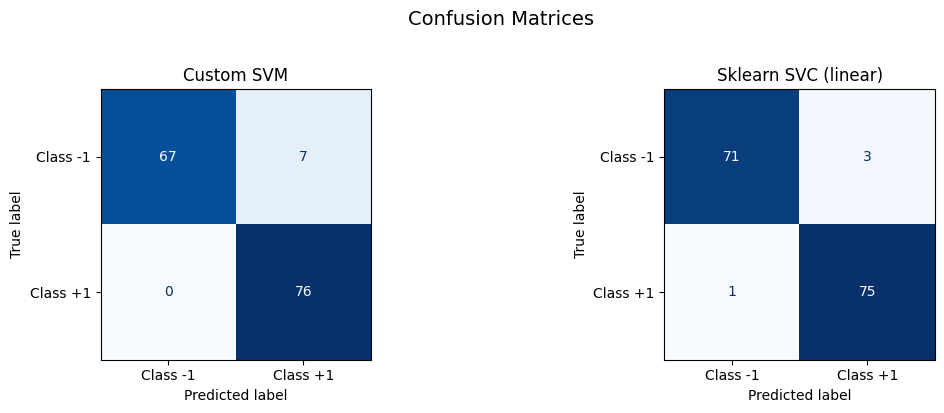

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [y_pred_custom, y_pred_sk],
    ['Custom SVM', 'Sklearn SVC (linear)']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class -1', 'Class +1'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Decision Boundary Visualization

/tmp/ipykernel_17/4062157802.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='upper right')


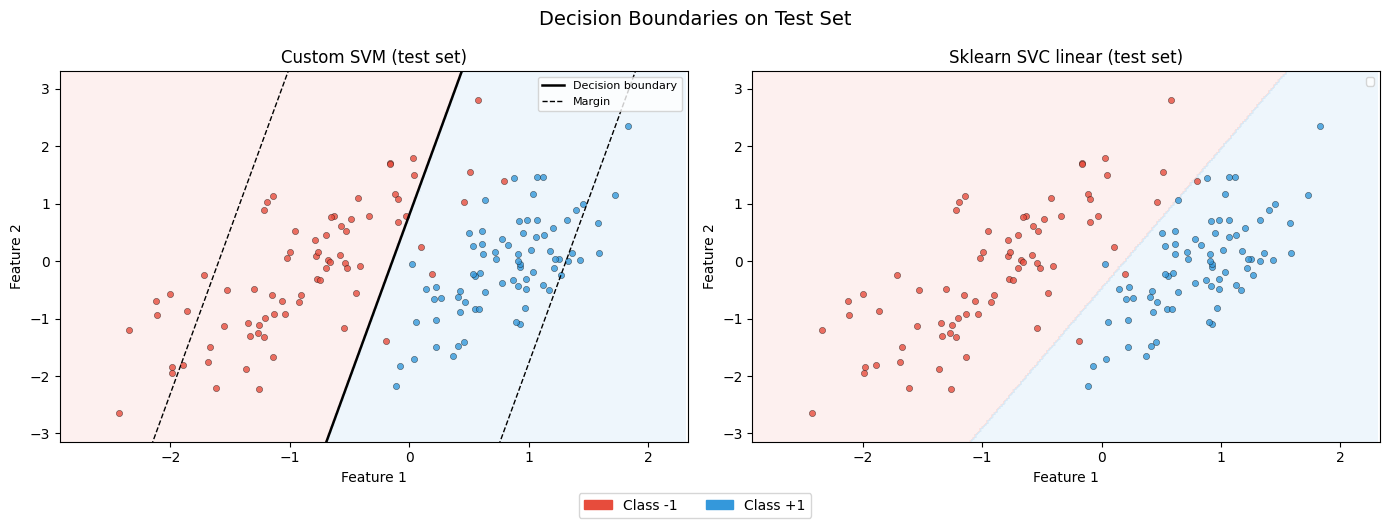

In [10]:
def plot_decision_boundary(model, X, y, title, ax, use_sklearn=False):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    if use_sklearn:
        Z = model.predict(grid)
    else:
        Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    cmap_bg = ListedColormap(['#fadbd8', '#d6eaf8'])
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)

    colors = {-1: '#e74c3c', 1: '#3498db'}
    for label, color in colors.items():
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], c=color, s=20, alpha=0.8,
                   edgecolors='k', linewidths=0.3)

    # Draw the decision hyperplane w.x + b = 0
    if not use_sklearn:
        x_line = np.linspace(x_min, x_max, 200)
        if model.w[1] != 0:
            y_boundary = -(model.w[0] * x_line + model.b) / model.w[1]
            y_margin_p = -(model.w[0] * x_line + model.b - 1) / model.w[1]
            y_margin_n = -(model.w[0] * x_line + model.b + 1) / model.w[1]
            ax.plot(x_line, y_boundary, 'k-',  linewidth=1.8, label='Decision boundary')
            ax.plot(x_line, y_margin_p, 'k--', linewidth=1.0, label='Margin')
            ax.plot(x_line, y_margin_n, 'k--', linewidth=1.0)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(fontsize=8, loc='upper right')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary(svm, X_test, y_test,
                       'Custom SVM (test set)', axes[0])

plot_decision_boundary(sklearn_svm, X_test, y_test,
                       'Sklearn SVC linear (test set)', axes[1], use_sklearn=True)

red_patch  = mpatches.Patch(color='#e74c3c', label='Class -1')
blue_patch = mpatches.Patch(color='#3498db', label='Class +1')
fig.legend(handles=[red_patch, blue_patch], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.suptitle('Decision Boundaries on Test Set', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Hyperparameter Sensitivity: Effect of C

/tmp/ipykernel_17/834977150.py:43: RuntimeWarning: overflow encountered in multiply
  dw = (1 / self.C) * self.w - (1 / n) * (mask * y_b) @ X_b
/tmp/ipykernel_17/834977150.py:73: RuntimeWarning: invalid value encountered in subtract
  self.w -= lr_t * dw
/tmp/ipykernel_17/834977150.py:86: RuntimeWarning: invalid value encountered in cast
  return np.sign(self.decision_function(X)).astype(int)
/tmp/ipykernel_17/834977150.py:86: RuntimeWarning: invalid value encountered in cast
  return np.sign(self.decision_function(X)).astype(int)


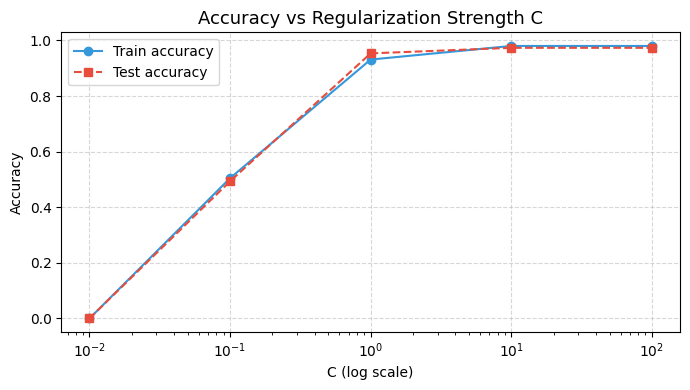


C value | Train Acc | Test Acc
-----------------------------------
   0.01 |      0.00% | 0.00%
   0.10 |     50.44% | 49.33%
   1.00 |     93.11% | 95.33%
  10.00 |     98.00% | 97.33%
 100.00 |     98.00% | 97.33%


In [11]:
C_values  = [0.01, 0.1, 1.0, 10.0, 100.0]
train_acc = []
test_acc  = []

for C in C_values:
    m = LinearSVM(C=C, lr=0.1, n_epochs=300, batch_size=32)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test,  m.predict(X_test)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(C_values, train_acc, 'o-', label='Train accuracy', color='#3498db')
ax.semilogx(C_values, test_acc,  's--', label='Test accuracy',  color='#e74c3c')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Regularization Strength C', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\nC value | Train Acc | Test Acc')
print('-' * 35)
for C, tr, te in zip(C_values, train_acc, test_acc):
    print(f'{C:7.2f} | {tr*100:9.2f}% | {te*100:.2f}%')

## 10. Summary

| Metric | Custom SVM | Sklearn SVC (linear) |
|--------|-----------|---------------------|
| Optimizer | Mini-batch SGD | LibLinear / LIBSVM (QP) |
| Kernel | Linear only | Linear |
| Accuracy (test) | see above | see above |

**Key takeaways:**

- The SGD-trained SVM lands very close to sklearn's QP-based solution on a linearly separable 2D dataset.
- A learning rate schedule (even a mild decay like `lr / (1 + 0.01 * t)`) makes convergence noticeably smoother than a fixed rate.
- `C` directly trades off margin width against misclassification tolerance. Very small C pushes for a wide margin at the cost of more training errors; very large C can overfit the training data.
- Feature scaling is not optional here. Without `StandardScaler`, gradient magnitudes across dimensions differ by orders of magnitude and convergence slows to a crawl.

**What this implementation does not have** (and sklearn does):

- Kernel trick (RBF, polynomial) for non-linear boundaries
- Dual optimization via SMO for high-dimensional sparse data
- Platt scaling for probability calibration
- Multi-class OvR / OvO support